## Imports and reading the Dataset

In [13]:
import re
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_curve, auc
from collections import Counter

# ==========================================
# 1. Setup: Imports, Data Loading & Preprocessing
# ==========================================

df = pd.read_csv("../dataset/train.csv")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Preprocessing the Dataset

In [14]:
# ==========================================
# 1. Multi-Label Train / Val / Test Split
# ==========================================

target_columns = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
num_classes = len(target_columns)
RARE_LABELS = ['threat', 'severe_toxic', 'identity_hate']

# 1. Split real-world data first (80/10/10) to avoid any leakage from augmentation
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# 2. Oversample rare labels ONLY in the training set
OVERSAMPLE_FACTOR = 4
rare_mask = train_df[RARE_LABELS].sum(axis=1) > 0
rare_rows = train_df[rare_mask]
train_df = pd.concat([train_df] + [rare_rows] * OVERSAMPLE_FACTOR, ignore_index=True)

# 3. Shuffle final training set
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} (oversampled)  Val: {len(val_df)}  Test: {len(test_df)}")

# ==========================================
# 2. Tokenizer, Vocabulary & DataLoaders
# ==========================================

TOKEN_RE = re.compile(r"[A-Za-z]+")
def custom_tokenize(text):
    return TOKEN_RE.findall(str(text).lower())

def build_vocab(texts):
    counter = Counter()
    for t in texts: counter.update(custom_tokenize(t))
    itos = ["<PAD>", "<UNK>"] + [word for word, freq in counter.items() if freq >= 1]
    stoi = {word: i for i, word in enumerate(itos)}
    return stoi, itos

custom_stoi, custom_itos = build_vocab(train_df["comment_text"].values)

def custom_encode(text, stoi, max_len=150):
    tokens = custom_tokenize(text)
    return [stoi.get(t, stoi["<UNK>"]) for t in tokens][:max_len]

class CustomDataset(Dataset):
    def __init__(self, df, stoi, target_cols):
        self.samples = [custom_encode(t, stoi) for t in df["comment_text"].values]
        self.labels = df[target_cols].values.astype(np.float32)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx], self.labels[idx]

def custom_collate_fn(batch):
    batch.sort(key=lambda x: len(x[0]), reverse=True)
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    max_len = lengths.max().item()
    padded = torch.zeros(len(sequences), max_len, dtype=torch.long)
    for i, seq in enumerate(sequences):
        seq_list = seq if len(seq) > 0 else [1]
        padded[i, :len(seq_list)] = torch.tensor(seq_list, dtype=torch.long)
    return padded, lengths, torch.tensor(np.array(labels), dtype=torch.float32)

# DataLoaders (Optimized batch sizes)
train_loader = DataLoader(CustomDataset(train_df, custom_stoi, target_columns), 
                          batch_size=128, shuffle=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(CustomDataset(val_df, custom_stoi, target_columns), 
                        batch_size=256, shuffle=False, collate_fn=custom_collate_fn)
test_loader = DataLoader(CustomDataset(test_df, custom_stoi, target_columns), 
                         batch_size=256, shuffle=False, collate_fn=custom_collate_fn)

# ==========================================
# 3. Loss Function (Dampened Weights)
# ==========================================

pos_weights = []
for col in target_columns:
    pos = train_df[col].sum()
    neg = len(train_df) - pos
    pos_weights.append(np.sqrt(neg / (pos + 1e-5)))

pos_weight_tensor = torch.tensor(pos_weights, dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

Train: 137176 (oversampled)  Val: 15957  Test: 15958


## LSTM Architcture

In [15]:
import torch
import torch.nn as nn

class VanillaLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, output_dim=6):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=1, batch_first=True, bidirectional=False)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3) # Optimized to 0.3
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x, lengths): # Added lengths to match pipeline
        emb = self.embedding(x)
        out, _ = self.lstm(emb) 
        mask = (x == 0).unsqueeze(-1)
        out = out.masked_fill(mask, -1e9)
        final = out.max(dim=1)[0]
        dense_out = self.relu(self.fc1(final))
        return self.fc2(self.dropout(dense_out))

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, output_dim=6):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # Scaling hidden_dim // 2 to maintain parameter parity with Vanilla
        # The output of BiLSTM is hidden_dim // 2 * 2 = hidden_dim
        self.lstm = nn.LSTM(embed_dim, hidden_dim // 2, num_layers=1, batch_first=True, bidirectional=True)
        
        self.fc1 = nn.Linear(hidden_dim, hidden_dim) 
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x, lengths): # Added lengths to match pipeline
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        mask = (x == 0).unsqueeze(-1)
        out = out.masked_fill(mask, -1e9)
        final = out.max(dim=1)[0]
        dense_out = self.relu(self.fc1(final))
        return self.fc2(self.dropout(dense_out))

## Training the Model

In [16]:
# 1. Setup the correct Loss Function
# BCEWithLogitsLoss combines a Sigmoid layer and the BCELoss in one single class.
# It is more numerically stable than using a plain Sigmoid followed by a BCELoss.
criterion = nn.BCEWithLogitsLoss()

def train_pipeline(model_class, name):
    # Ensure num_classes=6 is correctly passed down
    model = model_class(len(custom_itos), output_dim=6).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    
    best_f1, best_state = -1, None
    history = {"train_loss": [], "val_f1": []}
    
    for epoch in range(30):
        model.train()
        total_loss, count = 0, 0
        for x, lengths, y in train_loader:
            x, lengths, y = x.to(device), lengths.to(device), y.to(device)
            optimizer.zero_grad()
            
            # Using BCEWithLogitsLoss: Pass raw logits
            logits = model(x, lengths) 
            loss = criterion(logits, y.float()) # y must be float for BCE
            
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            
            total_loss += loss.item() * x.size(0)
            count += x.size(0)
            
        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for x, lengths, y in val_loader:
                x, lengths = x.to(device), lengths.to(device)
                
                # Apply Sigmoid here ONLY for evaluation/metrics
                logits = model(x, lengths)
                probs = torch.sigmoid(logits).cpu().numpy()
                
                binary_preds = (probs > 0.5).astype(int)
                preds.extend(binary_preds)
                targets.extend(y.cpu().numpy())
                
        val_f1 = f1_score(np.array(targets), np.array(preds), average='macro')
        
        epoch_loss = total_loss / count
        history["train_loss"].append(epoch_loss)
        history["val_f1"].append(val_f1)
        
        scheduler.step(val_f1)
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/30 | LR: {current_lr:.6f} | Train Loss: {epoch_loss:.4f} | Val F1: {val_f1:.4f}")
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            
    model.load_state_dict(best_state)
    return model, history


# Run training using the robust LSTM variants
print("Training Unidirectional LSTM...")
model_vanilla, hist_vanilla = train_pipeline(VanillaLSTM, "Vanilla LSTM")

print("Training Bidirectional BiLSTM...")
model_birnn, hist_birnn = train_pipeline(BiLSTM, "Bidirectional LSTM")

Training Unidirectional LSTM...
Epoch 01/30 | LR: 0.000500 | Train Loss: 0.1546 | Val F1: 0.4173
Epoch 02/30 | LR: 0.000500 | Train Loss: 0.0979 | Val F1: 0.4447
Epoch 03/30 | LR: 0.000500 | Train Loss: 0.0889 | Val F1: 0.4509
Epoch 04/30 | LR: 0.000500 | Train Loss: 0.0828 | Val F1: 0.5184
Epoch 05/30 | LR: 0.000500 | Train Loss: 0.0765 | Val F1: 0.5306
Epoch 06/30 | LR: 0.000500 | Train Loss: 0.0705 | Val F1: 0.5809
Epoch 07/30 | LR: 0.000500 | Train Loss: 0.0649 | Val F1: 0.6088
Epoch 08/30 | LR: 0.000500 | Train Loss: 0.0607 | Val F1: 0.6087
Epoch 09/30 | LR: 0.000500 | Train Loss: 0.0575 | Val F1: 0.6092
Epoch 10/30 | LR: 0.000500 | Train Loss: 0.0554 | Val F1: 0.6142
Epoch 11/30 | LR: 0.000500 | Train Loss: 0.0530 | Val F1: 0.6174
Epoch 12/30 | LR: 0.000500 | Train Loss: 0.0515 | Val F1: 0.6269
Epoch 13/30 | LR: 0.000500 | Train Loss: 0.0501 | Val F1: 0.6197
Epoch 14/30 | LR: 0.000500 | Train Loss: 0.0489 | Val F1: 0.6314
Epoch 15/30 | LR: 0.000500 | Train Loss: 0.0477 | Val F1: 

## Validation and Report

In [17]:
import numpy as np
import torch
from sklearn.metrics import classification_report, f1_score

# ==========================================
# 5. Evaluation, Threshold Tuning & Reports
# ==========================================

def evaluate_model(model, loader):
    model.eval()
    preds, targets, probs = [], [], []
    with torch.no_grad():
        for x, lengths, y in loader:
            x, lengths = x.to(device), lengths.to(device)
            logits = model(x, lengths)
            
            prob_batch = torch.sigmoid(logits).cpu().numpy()
            pred_batch = (prob_batch > 0.5).astype(int)
            
            probs.extend(prob_batch)
            preds.extend(pred_batch)
            targets.extend(y.numpy())
            
    return np.array(targets), np.array(preds), np.array(probs)

# 1. Evaluate on Validation Set first to find thresholds (Prevents Data Leakage)
print("Evaluating Validation Set to find optimal thresholds...")
y_true_val_v, _, y_prob_val_v = evaluate_model(model_vanilla, val_loader)
y_true_val_b, _, y_prob_val_b = evaluate_model(model_birnn, val_loader)

# 2. Find optimal thresholds per class for both models
optimal_thresholds_v = []
optimal_thresholds_b = []

print("\n--- Fast BiLSTM Optimal Thresholds ---")
for i, col in enumerate(target_columns):
    best_f1 = 0
    best_thresh = 0.5
    # Scan from 0.10 to 0.90
    for thresh in np.arange(0.1, 0.91, 0.01):
        temp_preds = (y_prob_val_b[:, i] > thresh).astype(int)
        score = f1_score(y_true_val_b[:, i], temp_preds, zero_division=0)
        
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh
            
    optimal_thresholds_b.append(best_thresh)
    print(f"{col:>15}: {best_thresh:.2f} (Max Val F1: {best_f1:.4f})")

# Silently find thresholds for the Vanilla model as well
for i in range(num_classes):
    best_f1 = 0
    best_thresh = 0.5
    for thresh in np.arange(0.1, 0.91, 0.01):
        temp_preds = (y_prob_val_v[:, i] > thresh).astype(int)
        score = f1_score(y_true_val_v[:, i], temp_preds, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh
    optimal_thresholds_v.append(best_thresh)

# 3. Evaluate the Test Set
print("\nEvaluating Test Set...")
y_true_v, y_pred_v_default, y_prob_v = evaluate_model(model_vanilla, test_loader)
y_true_b, y_pred_b_default, y_prob_b = evaluate_model(model_birnn, test_loader)

# 4. Overwrite predictions by applying the custom tuned thresholds
y_pred_v = np.zeros_like(y_prob_v)
y_pred_b = np.zeros_like(y_prob_b)

for i in range(num_classes):
    y_pred_v[:, i] = (y_prob_v[:, i] > optimal_thresholds_v[i]).astype(int)
    y_pred_b[:, i] = (y_prob_b[:, i] > optimal_thresholds_b[i]).astype(int)

# 5. Print Final Highly-Optimized Reports for the Instructor
print("\n================ LSTM REPORT (TUNED THRESHOLDS) ================")
print(classification_report(y_true_v, y_pred_v, target_names=target_columns, zero_division=0))

print("\n================ BiLSTM REPORT (TUNED THRESHOLDS) ================")
print(classification_report(y_true_b, y_pred_b, target_names=target_columns, zero_division=0))

Evaluating Validation Set to find optimal thresholds...

--- Fast BiLSTM Optimal Thresholds ---
          toxic: 0.51 (Max Val F1: 0.8076)
   severe_toxic: 0.51 (Max Val F1: 0.4931)
        obscene: 0.37 (Max Val F1: 0.8273)
         threat: 0.49 (Max Val F1: 0.4944)
         insult: 0.31 (Max Val F1: 0.7237)
  identity_hate: 0.48 (Max Val F1: 0.5686)

Evaluating Test Set...

================ LSTM REPORT (TUNED THRESHOLDS) ================
               precision    recall  f1-score   support

        toxic       0.84      0.74      0.79      1520
 severe_toxic       0.40      0.59      0.48       162
      obscene       0.82      0.78      0.80       856
       threat       0.41      0.54      0.47        37
       insult       0.71      0.76      0.74       808
identity_hate       0.45      0.46      0.45       138

    micro avg       0.75      0.74      0.74      3521
    macro avg       0.60      0.65      0.62      3521
 weighted avg       0.76      0.74      0.75      3521
  sa

## Graphs and Plots

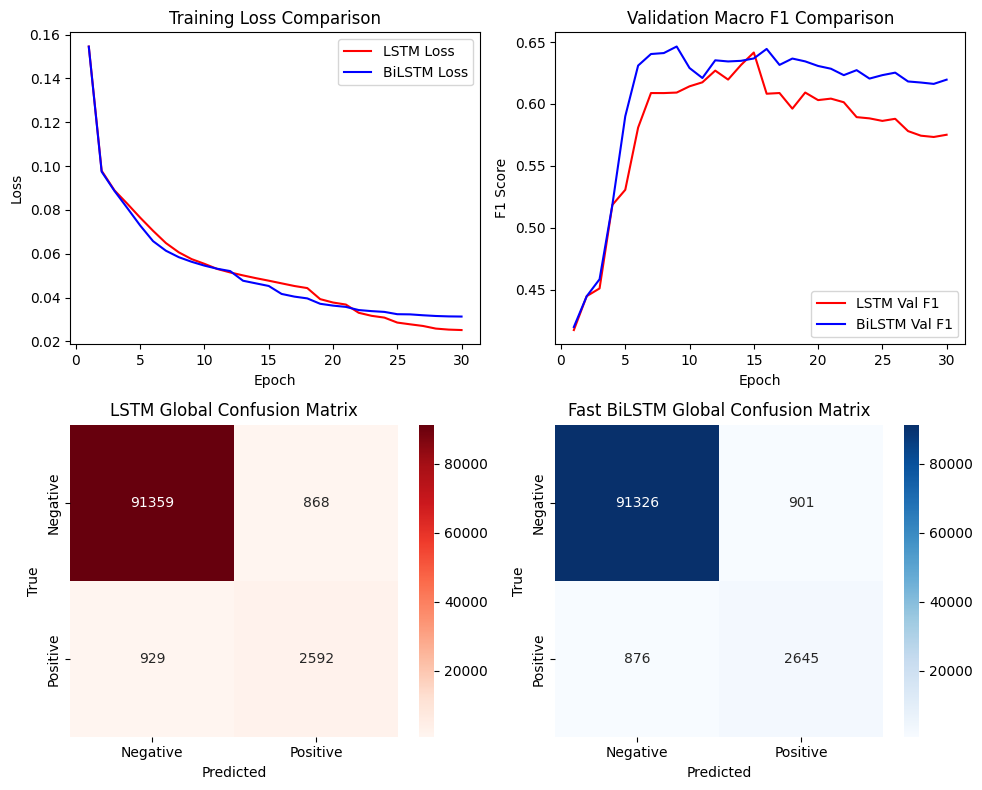

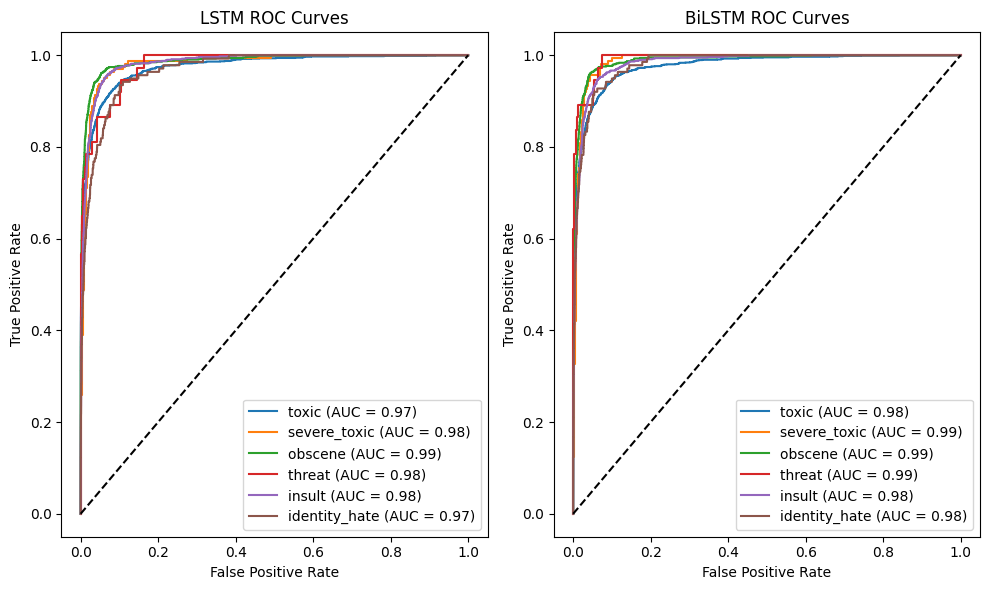

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix, roc_curve, auc

# ==========================================
# 6. Plots: Loss, F1, Confusion Matrices & ROC Curves
# ==========================================

epochs = range(1, 31)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 1. Training Loss Comparison
axes[0, 0].plot(epochs, hist_vanilla["train_loss"], label="LSTM Loss", color="red")
axes[0, 0].plot(epochs, hist_birnn["train_loss"], label="BiLSTM Loss", color="blue")
axes[0, 0].set_title("Training Loss Comparison")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

# 2. Validation F1 Comparison
axes[0, 1].plot(epochs, hist_vanilla["val_f1"], label="LSTM Val F1", color="red")
axes[0, 1].plot(epochs, hist_birnn["val_f1"], label="BiLSTM Val F1", color="blue")
axes[0, 1].set_title("Validation Macro F1 Comparison")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("F1 Score")
axes[0, 1].legend()

# 3. Global Confusion Matrices (Summed across all 6 target classes)
cm_v_global = multilabel_confusion_matrix(y_true_v, y_pred_v).sum(axis=0)
sns.heatmap(cm_v_global, annot=True, fmt="d", cmap="Reds", 
            xticklabels=["Negative", "Positive"], 
            yticklabels=["Negative", "Positive"], ax=axes[1, 0])
axes[1, 0].set_title("LSTM Global Confusion Matrix")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("True")

cm_b_global = multilabel_confusion_matrix(y_true_b, y_pred_b).sum(axis=0)
sns.heatmap(cm_b_global, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Negative", "Positive"], 
            yticklabels=["Negative", "Positive"], ax=axes[1, 1])
axes[1, 1].set_title("Fast BiLSTM Global Confusion Matrix")
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("True")

plt.tight_layout()
plt.show()

# ==========================================
# 7. ROC Curves (Per Class)
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Fast RNN ROC
for i, col in enumerate(target_columns):
    # y_true_v is already binarized shape [N, 6]
    fpr, tpr, _ = roc_curve(y_true_v[:, i], y_prob_v[:, i])
    axes[0].plot(fpr, tpr, label=f"{col} (AUC = {auc(fpr, tpr):.2f})")
    
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title("LSTM ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

# Fast BiLSTM ROC
for i, col in enumerate(target_columns):
    fpr, tpr, _ = roc_curve(y_true_b[:, i], y_prob_b[:, i])
    axes[1].plot(fpr, tpr, label=f"{col} (AUC = {auc(fpr, tpr):.2f})")
    
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title("BiLSTM ROC Curves")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()